# NovaCat — Operations Notebook

Query the NovaCat DynamoDB table and CloudWatch logs.

**Setup:** Run the *Imports & Setup* cell first, then use any section independently.

---
- **Interface 2** (DynamoDB): Sections 1–3 below
- **Interface 3** (CloudWatch): Section 4 below

**Section 2 subsections:** 2a Nova Summary · 2b Spectra · 2c Job Runs · 2d NovaRef Links · 2e Global References · 2f Name Mappings

## Imports & Setup

In [1]:
import sys
import os

# Add tools directory to path so we can import the modules
# Adjust this path if the notebook lives somewhere other than notebooks/
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'tools'))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from novacat_query import NovaCatQuery
from novacat_logs import NovaCatLogs

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.width', 120)

# Instantiate
q = NovaCatQuery()
logs = NovaCatLogs()

print('Ready.')

Ready.


---
## Section 1 — Table Dashboard

Aggregate counts across the entire NovaCat table.

> **Note:** Uses a full table scan. Fast at current catalog size.
> When the catalog grows, this will be replaced by a `STATS` item read.

In [2]:
stats = q.dashboard()
df_stats = q.dashboard_df()
df_stats

,metric,count
0,Total Novas,2
1,Active Novas,2
2,Quarantined Novas,0
3,Total Spectra Products,135
4,Spectra Valid,124
5,Spectra Quarantined,0
6,Spectra Unvalidated,11
7,Spectra Terminal Invalid,0
8,Photometry Tables,1
9,Total References,56


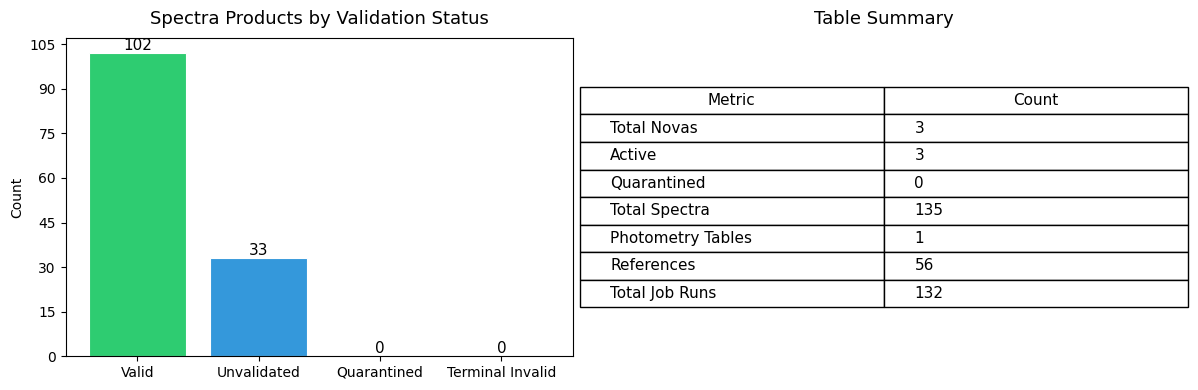

In [3]:
# ── Spectra validation breakdown (bar chart) ──────────────────────────────────
spectra_keys = [
    ('spectra_valid',            'Valid',            '#2ecc71'),
    ('spectra_unvalidated',      'Unvalidated',      '#3498db'),
    ('spectra_quarantined',      'Quarantined',      '#e67e22'),
    ('spectra_terminal_invalid', 'Terminal Invalid', '#e74c3c'),
]

labels  = [label for _, label, _ in spectra_keys]
values  = [stats[key] for key, _, _ in spectra_keys]
colors  = [color for _, _, color in spectra_keys]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart — spectra by status
axes[0].bar(labels, values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Spectra Products by Validation Status', fontsize=13, pad=10)
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
for i, v in enumerate(values):
    axes[0].text(i, v + 0.05, str(v), ha='center', va='bottom', fontsize=11)

# Summary stats table
summary_rows = [
    ['Total Novas',     stats['total_novas']],
    ['Active',          stats['active_novas']],
    ['Quarantined',     stats['quarantined_novas']],
    ['Total Spectra',   stats['total_spectra_products']],
    ['Photometry Tables', stats['photometry_tables']],
    ['References',      stats['total_references']],
    ['Total Job Runs',  stats['total_job_runs']],
]
axes[1].axis('off')
tbl = axes[1].table(
    cellText=summary_rows,
    colLabels=['Metric', 'Count'],
    loc='center',
    cellLoc='left',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 1.6)
axes[1].set_title('Table Summary', fontsize=13, pad=10)

plt.tight_layout()
plt.show()

---
## Section 2 — Per-Nova Views

Set `NOVA_NAME` once; all cells in this section use it.

In [7]:
NOVA_NAME = 'V1324_Sco'  # ← change this
# NOVA_NAME = 'V1369 Cen'  # ← change this
# NOVA_NAME = 'V2572 Sgr'  # ← change this

### 2a — Nova Summary

In [5]:
summary = q.summary(NOVA_NAME)
nova = summary['nova']

if nova:
    print(f"Nova ID:          {nova.get('nova_id')}")
    print(f"Status:           {nova.get('status')}")
    print(f"RA (deg):         {nova.get('ra_deg')}")
    print(f"Dec (deg):        {nova.get('dec_deg')}")
    print(f"Discovery Date:   {nova.get('discovery_date')}")
    print(f"Aliases:          {', '.join(nova.get('aliases', []))}")
    print()
    print(f"Spectra products: {len(summary['spectra'])}")
    print(f"References:       {len(summary['refs'])}")
    print(f"Job runs:         {len(summary['jobs'])}")
    print(f"Files:            {len(summary['files'])}")
    print(f"Created:          {nova.get('created_at')}")
    print(f"Updated:          {nova.get('updated_at')}")
else:
    print(f'Nova not found: {NOVA_NAME}')

Nova ID:          4ef2e92c-3277-4596-9afb-b5bfcdd990e9
Status:           ACTIVE
RA (deg):         277.903125
Dec (deg):        -32.599361111111115
Discovery Date:   1973-01-00
Aliases:          NAME Bateson's Nova, AAVSO 1825-32, NOVA Sgr 1969, SV* BV  1262, V2572 Sgr

Spectra products: 0
References:       9
Job runs:         0
Files:            0
Created:          2026-04-01T01:16:27Z
Updated:          2026-04-01T01:16:35.767122+00:00


### 2b — Spectra Products

In [8]:
df_spectra = q.spectra(NOVA_NAME)
print(f'{len(df_spectra)} spectra product(s) found')
df_spectra

0 spectra product(s) found


""


In [14]:
# Instrument summary — one row per instrument with counts + wavelength coverage
df_instruments = q.spectra_instrument_summary(NOVA_NAME)
print(f'{len(df_instruments)} instrument(s) found')
df_instruments

4 instrument(s) found


,instrument,total,valid,unvalidated,quarantined,terminal_invalid,em_min_nm,em_max_nm,snr_median
3,XSHOOTER,54,54,0,0,0,298.9,2479.0,158.8
0,FEROS,38,38,0,0,0,352.7,921.8,103.9
2,UVES,36,36,0,0,0,302.4,1042.6,17.3
1,FORS2-SPEC,5,0,5,0,0,375.1,774.9,28.4


In [15]:
df = q.spectra_by_instrument("V1369 Cen")
print(df[df["instrument"].isin(["UVES", "XSHOOTER", "FEROS", "FORS2-SPEC"])][
    ["instrument", "validation_status", "attempt_count"]
].value_counts().sort_index())

instrument  validation_status  attempt_count
FEROS       VALID              1                38
FORS2-SPEC  UNVALIDATED        1                 5
UVES        VALID              1                36
XSHOOTER    VALID              1                54
Name: count, dtype: int64


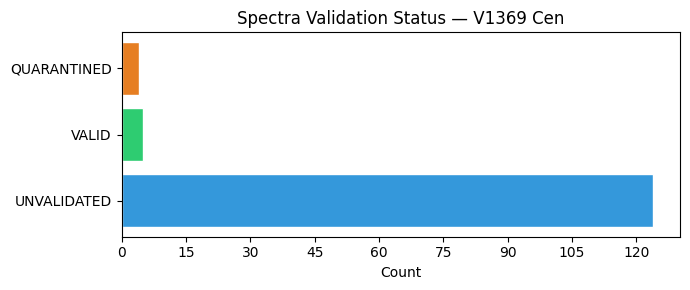

In [8]:
# Spectra status breakdown for this nova
if not df_spectra.empty and 'validation_status' in df_spectra.columns:
    status_counts = df_spectra['validation_status'].value_counts()
    status_colors = {
        'VALID':            '#2ecc71',
        'UNVALIDATED':      '#3498db',
        'QUARANTINED':      '#e67e22',
        'TERMINAL_INVALID': '#e74c3c',
    }
    bar_colors = [status_colors.get(s, '#95a5a6') for s in status_counts.index]

    fig, ax = plt.subplots(figsize=(7, 3))
    ax.barh(status_counts.index, status_counts.values, color=bar_colors, edgecolor='white')
    ax.set_xlabel('Count')
    ax.set_title(f'Spectra Validation Status — {NOVA_NAME}', fontsize=12)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()
else:
    print('No spectra data to plot.')

### 2c — Job Run History

In [13]:
df_jobs = q.jobs(NOVA_NAME)
print(f'{len(df_jobs)} job run(s) found')
df_jobs

0 job run(s) found


""


In [ ]:
# Drill into attempts for a specific job run
# Set JOB_RUN_ID to a job_run_id from the table above (or leave None for all)
JOB_RUN_ID = None  # e.g. '5a4fce02-3b02-4b5c-8d06-541d9f2d4f60'

df_attempts = q.attempts(NOVA_NAME, job_run_id=JOB_RUN_ID)
print(f'{len(df_attempts)} attempt(s) found')
df_attempts

### 2d — References

In [ ]:
df_refs = q.refs(NOVA_NAME)
print(f'{len(df_refs)} reference(s) found')
df_refs

### 2e — Global Reference Entities

The raw global `REFERENCE#<bibcode>` items as written by `refresh_references`. Complements **2d** (NovaRef links) by showing the full Reference record exactly as stored.

In [ ]:
df_global_refs = q.global_references(NOVA_NAME)
print(f'{len(df_global_refs)} global reference entity/entities found')
df_global_refs

### 2f — Name Mappings

All `NAME#<normalized>` items that resolve to this nova. Shows every alias and the source that registered it.

In [ ]:
df_name_mappings = q.name_mappings(NOVA_NAME)
print(f'{len(df_name_mappings)} name mapping(s) found')
df_name_mappings

---
## Section 3 — Multi-Nova Comparison

Compare spectra validation status across several novas at once.

In [ ]:
# Add nova names as you ingest them
NOVA_LIST = ['V1324 Sco']

rows = []
for name in NOVA_LIST:
    try:
        nova_id = q.resolve_nova_id(name)
        df_s = q.spectra(name)
        nova_item = q.get_nova_item(nova_id) if nova_id else {}
        rows.append({
            'name':              name,
            'status':            (nova_item or {}).get('status'),
            'discovery_date':    (nova_item or {}).get('discovery_date'),
            'n_spectra':         len(df_s),
            'n_valid':           (df_s['validation_status'] == 'VALID').sum() if not df_s.empty else 0,
            'n_quarantined':     (df_s['validation_status'] == 'QUARANTINED').sum() if not df_s.empty else 0,
            'n_unvalidated':     (df_s['validation_status'] == 'UNVALIDATED').sum() if not df_s.empty else 0,
        })
    except ValueError as e:
        rows.append({'name': name, 'status': f'NOT FOUND: {e}'})

pd.DataFrame(rows)

---
## Section 4 — CloudWatch Logs

### 4a — Trace a Full Execution by correlation_id

Paste the `correlation_id` printed by `nova-ingest.sh` when you triggered the run.

In [ ]:
CORRELATION_ID = ''  # ← paste correlation_id here

if not CORRELATION_ID:
    print('Set CORRELATION_ID above.')
else:
    df_trace = logs.trace(CORRELATION_ID, lookback_hours=24)
    print(f'\n{len(df_trace)} log event(s) found')
    df_trace

In [ ]:
# Summarize the trace: one row per workflow state transition
if 'df_trace' in dir() and not df_trace.empty:
    cols = ['timestamp', 'workflow_name', 'state_name', 'level', 'message',
            'nova_id', 'error_classification']
    available = [c for c in cols if c in df_trace.columns]
    display(df_trace[available])
else:
    print('Run the trace cell above first.')

### 4b — Recent Activity

In [ ]:
# What's been happening in the last N minutes across all NovaCat Lambdas?
LOOKBACK_MINUTES = 15
WORKFLOW_FILTER  = None   # e.g. 'refresh_references', or None for all

df_recent = logs.recent(minutes=LOOKBACK_MINUTES, workflow=WORKFLOW_FILTER)
print(f'\n{len(df_recent)} event(s) in the last {LOOKBACK_MINUTES} minutes')
df_recent

### 4c — Error Scan

In [ ]:
# Quick health check: any errors in the last hour?
df_errors = logs.errors(hours=1)
print(f'\n{len(df_errors)} error(s) in the last hour')

if not df_errors.empty:
    display(df_errors[['timestamp', 'workflow_name', 'state_name',
                        'message', 'error_classification', 'log_group']])

### 4d — Job Run Timeline

In [ ]:
# All workflow activity in the last 24 hours
df_job_runs = logs.job_runs(hours=24)
print(f'\n{len(df_job_runs)} job run event(s) in the last 24h')
df_job_runs

In [ ]:
# Timeline: events per workflow over time
if not df_job_runs.empty and 'timestamp' in df_job_runs.columns and 'workflow_name' in df_job_runs.columns:
    df_plot = df_job_runs.dropna(subset=['timestamp', 'workflow_name'])
    workflows = df_plot['workflow_name'].unique()

    fig, ax = plt.subplots(figsize=(12, max(3, len(workflows))))
    for i, wf in enumerate(sorted(workflows)):
        ts = df_plot[df_plot['workflow_name'] == wf]['timestamp']
        ax.scatter(ts, [i] * len(ts), s=40, label=wf, zorder=3)

    ax.set_yticks(range(len(sorted(workflows))))
    ax.set_yticklabels(sorted(workflows))
    ax.set_xlabel('Time (UTC)')
    ax.set_title('Workflow Activity Timeline (last 24h)', fontsize=12)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()
else:
    print('No job run data to plot.')

In [11]:


df = q.spectra_by_instrument("V1369 Cen")
feros = df[(df["instrument"] == "FEROS") & (df["validation_status"] == "QUARANTINED")]
print(feros[["data_product_id", "raw_s3_key"]].head(3))

df = q.spectra_by_instrument("V1369 Cen")
fors2 = df[(df["instrument"] == "FORS2-SPEC")]
print(fors2[["data_product_id", "raw_s3_key"]].head(3))

                          data_product_id                                                   raw_s3_key
127  f7b50cf6-fff0-505c-8e5b-5aaddc681d85  raw/50de4512-f439-48ac-ba53-da4c22a82ad6/ESO/f7b50cf6-ff...
38   47f6b45f-bac9-5fcd-805e-2930e04a6b6a  raw/50de4512-f439-48ac-ba53-da4c22a82ad6/ESO/47f6b45f-ba...
82   a99223bf-21a7-5f07-a9e8-57b47fcd1c6f  raw/50de4512-f439-48ac-ba53-da4c22a82ad6/ESO/a99223bf-21...
                         data_product_id raw_s3_key
21  26a10209-a971-5573-b820-2e38945bd12e        NaN
23  27f88da2-4fdc-57a0-9141-2cf70b84f4d9        NaN
63  85097340-1fdc-5239-ba01-e7827d0b3b08        NaN


In [ ]:
# import os
# bucket = os.environ["NOVA_CAT_PRIVATE_BUCKET"]
# bucket = feros["raw_s3_key"].iloc[0].split("/")[0]  # if key includes bucket
bucket = "novacat-storageprivatedatabucketdf2b0e10-pcpe6fbz97et"
s3_key_feros = feros["raw_s3_key"].iloc[0]
s3_key_fors2 = fors2["raw_s3_key"].iloc[0]

!aws s3 cp s3://{bucket}/{s3_key_feros} /Users/tfinzell/Downloads/tmp_spectra/feros_sample.fits
!aws s3 cp s3://{bucket}/{s3_key_fors2} /Users/tfinzell/Downloads/tmp_spectra/fors2_sample.fits

download: s3://novacat-storageprivatedatabucketdf2b0e10-pcpe6fbz97et/raw/50de4512-f439-48ac-ba53-da4c22a82ad6/ESO/f7b50cf6-fff0-505c-8e5b-5aaddc681d85.fits to ../../../../../Downloads/tmp_spectra/feros_sample.fits


In [9]:
from astropy.io import fits
hdul = fits.open("/Users/tfinzell/Downloads/tmp_spectra/feros_sample.fits")
hdul[1].columns

ColDefs(
    name = 'WAVE'; format = '189649D'; unit = 'angstrom'
    name = 'FLUX'; format = '189649E'; unit = 'adu'
    name = 'ERR'; format = '189649E'; unit = 'adu'
)